This cell installs the necessary libraries: `opencv-python` for image processing, `imgbeddings` for generating image embeddings, `pillow` for image manipulation, and `psycopg2-binary` for database connectivity.

In [1]:
!pip install opencv-python imgbeddings pillow psycopg2-binary

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 84.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 99.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 8.4 MB/s eta 0:00:00
  Created wheel for imgbeddings: filename=imgbeddings-0.1.0-py3-none-any.whl size=9321 sha256=853577a7f7bab8c2f9a70ebbd4d96a59288d70c8d21b58f0ea262bcd5b98c13e
  Stored in directory: /root/.cache/pip/wheels/65/7e/2a/58d9a6cfc8f64dceb35fc786fb7344f5ba649d62aca56e6463
Successfully built imgbeddings


This cell imports the required libraries, including `dlib` for face detection, `cv2` for image processing, `os` for interacting with the operating system, `PIL` for image manipulation, `numpy` for numerical operations, `matplotlib.pyplot` for plotting, and `sklearn.metrics.pairwise` for calculating cosine similarity. It also initializes the dlib face detector and the imgbeddings model.

In [4]:
import dlib
import cv2
import os
from PIL import Image, ImageEnhance, ImageFilter
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from imgbeddings import imgbeddings

detector = dlib.get_frontal_face_detector()
ibed = imgbeddings()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:939: FutureWarning: The `force_filename` parameter is deprecated as a new caching system, which keeps the filenames as they are on the Hub, is now in place.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


patch32_v1.onnx:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/clip/processing_clip.py:129: FutureWarning: `feature_extractor` is deprecated and will be removed in v5. Use `image_processor` instead.
  warnings.warn(


This cell creates the necessary directories for storing cropped faces and face embeddings.

In [5]:
# Create output directory
os.makedirs("stored-faces", exist_ok=True)
folder = "stored-faces"

embeddings_dir = "face_embeddings"
os.makedirs(embeddings_dir, exist_ok=True)

This cell displays the images from the specified reference directory (`/content/drive/MyDrive/matched-face/`). It loads each image, displays it in a grid format, and includes the filename as the title for each subplot.

Displaying images from: /content/reference_face


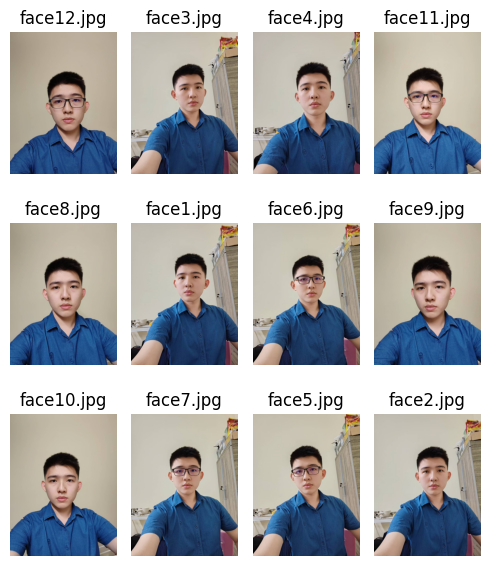

In [6]:
reference_dir = "/content/reference_face" #upload the reference face image

print(f"Displaying images from: {reference_dir}")

# Get list of image files
image_files = [f for f in os.listdir(reference_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]

if not image_files:
    print("No images found in the directory.")
else:
    # Determine grid size
    n_images = len(image_files)
    cols = 4  # Number of columns
    rows = (n_images + cols - 1) // cols # Calculate rows needed

    plt.figure(figsize=(5, rows * 2)) # Adjust figure size based on rows

    for i, filename in enumerate(image_files):
        image_path = os.path.join(reference_dir, filename)
        try:
            img = Image.open(image_path)
            plt.subplot(rows, cols, i + 1)
            plt.imshow(img)
            plt.title(filename)
            plt.axis('off')
        except Exception as e:
            print(f"Could not load or display {filename}: {e}")

    plt.tight_layout()
    plt.show()

This cell defines three functions:
- `enhance_face`: Enhances the sharpness, contrast, and brightness of a PIL image and applies a slight Gaussian blur.
- `crop_faces`: Detects faces in an image, crops them with a margin, enhances the cropped faces using `enhance_face`, saves the cropped faces, and returns a list of enhanced PIL images of the cropped faces.
- `get_all_embeddings`: Takes an image path, crops the faces using `crop_faces`, and generates embeddings for each cropped face using the `imgbeddings` model.
- `display_match`: Displays the matched face if a similarity score above 90% is achieved.
- `find_most_similar_face`: Takes a query image path and an embeddings file, finds the most similar face in the embeddings file based on cosine similarity, and returns the index, score, filename, and face index of the most similar face.

In [16]:
def enhance_face(pil_img):
    # Convert to RGB just in case
    pil_img = pil_img.convert("RGB")

    # Increase sharpness
    enhancer = ImageEnhance.Sharpness(pil_img)
    pil_img = enhancer.enhance(1.0)  # 1.0 = original, >1 = sharper

    # Increase contrast
    enhancer = ImageEnhance.Contrast(pil_img)
    pil_img = enhancer.enhance(1.1)  # 1.0 = original, >1 = more contrast

    # Optional: Slight brightness adjustment
    enhancer = ImageEnhance.Brightness(pil_img)
    pil_img = enhancer.enhance(1.25)

    # Optional: Slight Gaussian blur to reduce noise (use small radius)
    pil_img = pil_img.filter(ImageFilter.GaussianBlur(radius=1))

    return pil_img

def crop_faces(image_path, upsample_times=1):
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error loading image from {image_path}")
        return [] # Return empty list if image not loaded

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    detector = dlib.get_frontal_face_detector()
    faces = detector(img_rgb, upsample_times)

    cropped_faces = []
    for i, face in enumerate(faces):
        x1, y1, x2, y2 = face.left(), face.top(), face.right(), face.bottom()

        # Add margin
        margin = 0.2
        w, h = x2 - x1, y2 - y1
        x1 = max(int(x1 - w * margin), 0)
        y1 = max(int(y1 - h * margin), 0)
        x2 = min(int(x2 + w * margin), img.shape[1])
        y2 = min(int(y2 + h * margin), img.shape[0])

        cropped = img_rgb[y1:y2, x1:x2]
        pil_img = Image.fromarray(cropped)
        pil_img = enhance_face(pil_img)

        # Save the cropped face
        save_path = os.path.join("stored-faces", f"{os.path.basename(image_path).split('.')[0]}_face_{i}.png")
        pil_img.save(save_path)

        cropped_faces.append(pil_img)

    return cropped_faces

def get_all_embeddings(image_path):
    pil_faces = crop_faces(image_path)
    ibed = imgbeddings()
    embeddings = []
    for pil_face in pil_faces:
        embeddings.append(ibed.to_embeddings(pil_face)[0])
    return embeddings


# Re-define the display_match function with the corrected filename parsing
def display_match(image_path, face_index, score):
    if image_path is not None and face_index is not None and score is not None and score > 0.90:
        print("We found a match.")
        print(f"The confidence score for this match up is {score[0][0]*100:.2f}%\n")

        try:
            pil_faces = crop_faces(image_path)
            if face_index < len(pil_faces):
                 plt.imshow(pil_faces[face_index])
                 plt.axis('off')
                 plt.show()
            else:
                print(f"Error: Face index {face_index} is out of bounds for the image {image_path}")

        except Exception as e:
            print(f"Error displaying match: {e}")
            print(f"Attempted to load image from: {image_path}")
            print(f"Attempted to use face index: {face_index}")


    else:
        print("No similar face found.")


def find_most_similar_face(query_path, embeddings_file):
    query_emb = get_all_embeddings(query_path)

    if not query_emb:
        print("No face detected in the query image.")
        return None, None, None, None

    try:
        db_embs_data = np.load(embeddings_file, allow_pickle=True)
    except FileNotFoundError:
        print(f"Embeddings file not found at {embeddings_file}")
        return None, None, None, None

    best_score = -1
    best_idx = -1
    best_filename = None
    best_face_index_in_image = None

    for i, (db_emb, filename, face_index_in_image) in enumerate(db_embs_data):
        for q_emb in query_emb:
            if q_emb.ndim == 1:
                q_emb = q_emb.reshape(1, -1)
            if db_emb.ndim == 1:
                db_emb = db_emb.reshape(1, -1)
            score = cosine_similarity(q_emb, db_emb)
            if score > best_score:
                best_score = score
                best_idx = i
                best_filename = filename
                best_face_index_in_image = face_index_in_image


    return best_idx, best_score, best_filename, best_face_index_in_image

This cell iterates through the reference images, crops the faces from each image, generates embeddings for each cropped face, and stores the embeddings along with the corresponding filename and face index. Finally, it saves all the collected embeddings to a single `.npy` file.

In [8]:
reference_dir = "/content/reference_face"
embeddings_dir = "face_embeddings"
all_embeddings_data = []

for filename in os.listdir(reference_dir):
    if filename.lower().endswith(('.jpg', '.png', '.jpeg')):
        image_path = os.path.join(reference_dir, filename)
        try:
            pil_faces = crop_faces(image_path)
            ibed = imgbeddings()
            embeddings = ibed.to_embeddings(pil_faces) # Get embeddings for all faces in the image
            for i, emb in enumerate(embeddings):
                 all_embeddings_data.append((emb, filename, i)) # Store embedding, filename, and face index
            print(f"Processed {filename}")
        except Exception as e:
            print(f"Could not process {filename}: {e}")

if all_embeddings_data:
    all_embeddings_array = np.array(all_embeddings_data, dtype=object) # Use dtype=object for mixed types
    single_embedding_filepath = os.path.join(embeddings_dir, "all_face_embeddings.npy")
    np.save(single_embedding_filepath, all_embeddings_array)
    print(f"Saved all embeddings to {single_embedding_filepath}")
else:
    print("No faces found in the reference images.")

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Processed face12.jpg


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Processed face3.jpg


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

...

Processed face7.jpg


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Processed face5.jpg


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Processed face2.jpg
Saved all embeddings to face_embeddings/all_face_embeddings.npy


This cell loads a sample image, enhances it using the `enhance_face` function, and then displays both the original and enhanced images side by side for comparison.

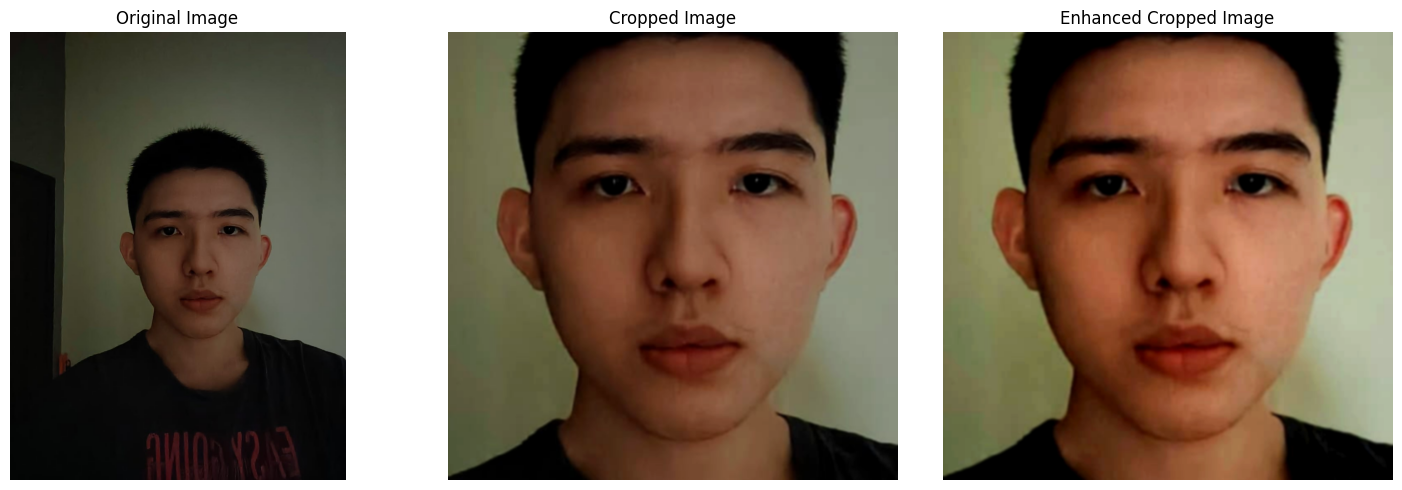

In [17]:
# Load a sample image
sample_image_path = os.path.join("sample.jpg")
original_img = Image.open(sample_image_path)

# Crop faces from the image
cropped_faces = crop_faces(sample_image_path)

if cropped_faces:
    # Assuming only one face is detected, take the first cropped face
    cropped_img = cropped_faces[0]

    # Enhance the cropped image
    enhanced_cropped_img = enhance_face(cropped_img.copy()) # Use a copy to avoid modifying the original

    # Display both images
    plt.figure(figsize=(15, 5)) # Increased figure size for 3 images

    plt.subplot(1, 3, 1) # Changed to 1x3 grid, first plot
    plt.imshow(original_img)
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 3, 2) # Changed to 1x3 grid, second plot
    plt.imshow(cropped_img)
    plt.title("Cropped Image")
    plt.axis('off')

    plt.subplot(1, 3, 3) # Changed to 1x3 grid, third plot
    plt.imshow(enhanced_cropped_img)
    plt.title("Enhanced Cropped Image")
    plt.axis('off')

    plt.tight_layout() # Adjust layout to prevent titles overlapping
    plt.show()
else:
    print("No faces detected in the image.")

This cell finds the most similar face in the saved embeddings file to the query image (`me.jpg`) using the `find_most_similar_face` function. It then displays the query image and the original matched image if a match with a confidence score above 90% is found.

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:939: FutureWarning: The `force_filename` parameter is deprecated as a new caching system, which keeps the filenames as they are on the Hub, is now in place.
  warnings.warn(


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/clip/processing_clip.py:129: FutureWarning: `feature_extractor` is deprecated and will be removed in v5. Use `image_processor` instead.
  warnings.warn(


We found a match.
The confidence score for this match up is 95.22%



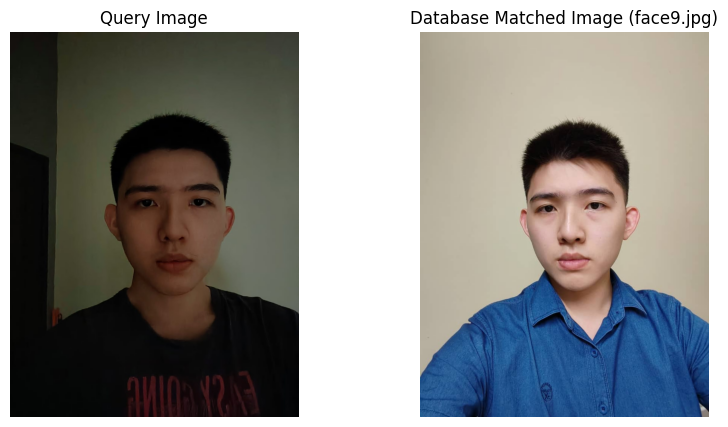

In [19]:
embeddings_dir = "face_embeddings"
query_image_path = "/content/sample.jpg"
embeddings_file = os.path.join(embeddings_dir, "all_face_embeddings.npy")
stored_faces_dir = "stored-faces" # Define the directory for stored faces

idx, score, filename, face_index_in_image = find_most_similar_face(query_image_path, embeddings_file)

# The display_match function now needs the original image path and the face index within that image
original_matched_image_path = os.path.join("/content/reference_face/", filename)

if score is not None and score > 0.90:
    print("We found a match.")
    print(f"The confidence score for this match up is {score[0][0]*100:.2f}%\n")

    plt.figure(figsize=(15, 5))

    # Display the query image
    plt.subplot(1, 3, 1)
    query_img = Image.open(query_image_path)
    plt.imshow(query_img)
    plt.title("Query Image")
    plt.axis('off')

    # Display the original matched image
    plt.subplot(1, 3, 2)
    try:
        original_matched_img = Image.open(original_matched_image_path)
        plt.imshow(original_matched_img)
        plt.title(f"Database Matched Image ({filename})")
        plt.axis('off')
    except FileNotFoundError:
         print(f"Error: Original matched image not found at {original_matched_image_path}")


    plt.show()

else:
    print("No similar face found.")
    print(f"The confidence score for this match up is {score[0][0]*100:.2f}%\n")

    plt.figure(figsize=(15, 5))

    # Display the query image
    plt.subplot(1, 3, 1)
    query_img = Image.open(query_image_path)
    plt.imshow(query_img)
    plt.title("Query Image")
    plt.axis('off')